#Credit Risk Prediction

## Problem Statement
Predict whether a loan applicant is likely to **default** on a loan based on
demographic and financial information. The target variable `Loan_Status` is
binary (`Y` = approved / loan repaid, `N` = denied / defaulted).

## Approach
1. Load the Loan Prediction dataset.
2. Explore data, identify and handle missing values.
3. Visualize key features (loan amount, education, income, credit history).
4. Encode categorical variables and split into train/test.
5. Train Logistic Regression and Decision Tree classifiers.
6. Evaluate using accuracy and a confusion matrix.

## Dataset
The Loan Prediction dataset (Analytics Vidhya / Kaggle) with **614 rows** and
**13 columns** including `Gender`, `Married`, `Education`, `ApplicantIncome`,
`LoanAmount`, `Credit_History`, and the target `Loan_Status`.

## 1. Import Libraries

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,classification_report, ConfusionMatrixDisplay)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", None)


## 2. Load and Inspect the Data

In [22]:
from google.colab import files
uploaded = files.upload()

Saving loan_data.csv to loan_data (3).csv


In [23]:
df = pd.read_csv("loan_data.csv")
print("Shape:", df.shape)
df.head()


Shape: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP1000,Male,Yes,3+,Graduate,No,4022,0,119.0,360.0,1.0,Rural,Y
1,LP1001,Male,No,0,Not Graduate,Yes,10398,1662,255.0,360.0,1.0,Urban,Y
2,LP1002,Female,No,0,Graduate,No,7425,4750,52.0,360.0,1.0,Rural,Y
3,LP1003,Male,Yes,1,Graduate,No,15989,0,70.0,180.0,0.0,Semiurban,N
4,LP1004,Male,Yes,0,Graduate,No,1942,2525,51.0,360.0,0.0,Urban,N


In [24]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             603 non-null    object 
 2   Married            603 non-null    object 
 3   Dependents         602 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      585 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    int64  
 8   LoanAmount         595 non-null    float64
 9   Loan_Amount_Term   605 non-null    float64
 10  Credit_History     562 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(3), int64(2), object(8)
memory usage: 62.5+ KB


In [25]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Loan_ID,614,614,LP1613,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,603,2,Male,479,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Married,603,2,Yes,393,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,602,4,0,346,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education,614,2,Graduate,485,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Self_Employed,585,2,No,507,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ApplicantIncome,614.0,NaN,NaN,NaN,5970.630293,3870.243093,944.0,3368.75,5076.5,7517.75,31354.0
CoapplicantIncome,614.0,NaN,NaN,NaN,1401.236156,1853.424614,0.0,0.0,976.0,2109.5,17849.0
LoanAmount,595.0,NaN,NaN,NaN,151.436975,80.187306,32.0,94.0,135.0,191.5,679.0
Loan_Amount_Term,605.0,NaN,NaN,NaN,336.099174,65.826307,60.0,360.0,360.0,360.0,480.0


## 3. Handle Missing Values

In [26]:
# Count missing values per column
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
print("Missing values per column:")
print(missing)


Missing values per column:
Credit_History      52
Self_Employed       29
LoanAmount          19
Dependents          12
Married             11
Gender              11
Loan_Amount_Term     9
dtype: int64


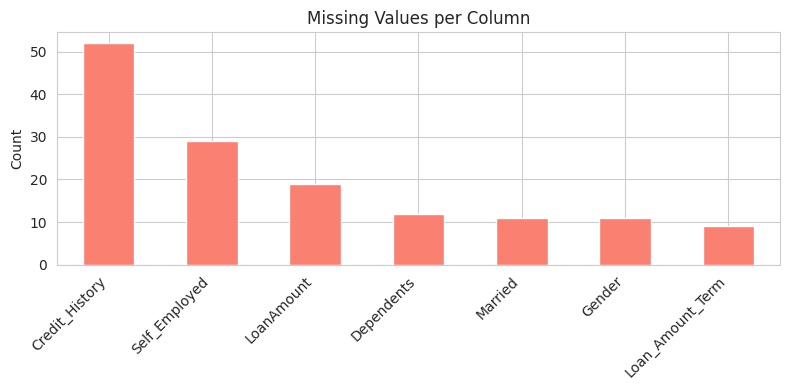

In [27]:
# Visualise missingness
plt.figure(figsize=(8, 4))
missing.plot(kind="bar", color="salmon")
plt.title("Missing Values per Column")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [28]:
# Strategy:
#   - Categorical columns -> fill with mode (most common value)
#   - Numeric columns     -> fill with median (robust to outliers)
categorical_cols = ["Gender", "Married", "Dependents", "Self_Employed"]
numeric_cols     = ["LoanAmount", "Loan_Amount_Term", "Credit_History"]

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Confirm no missing values remain
print("Missing values after imputation:", df.isnull().sum().sum())


Missing values after imputation: 0


## 4. Exploratory Data Analysis

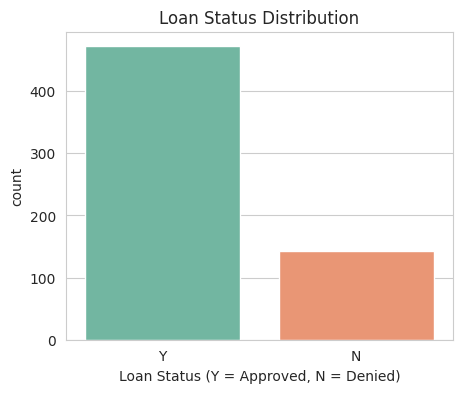

Approval rate: 0.769


In [29]:
# Target distribution
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="Loan_Status", hue="Loan_Status",
              palette="Set2", legend=False)
plt.title("Loan Status Distribution")
plt.xlabel("Loan Status (Y = Approved, N = Denied)")
plt.show()

print("Approval rate:", (df["Loan_Status"] == "Y").mean().round(3))


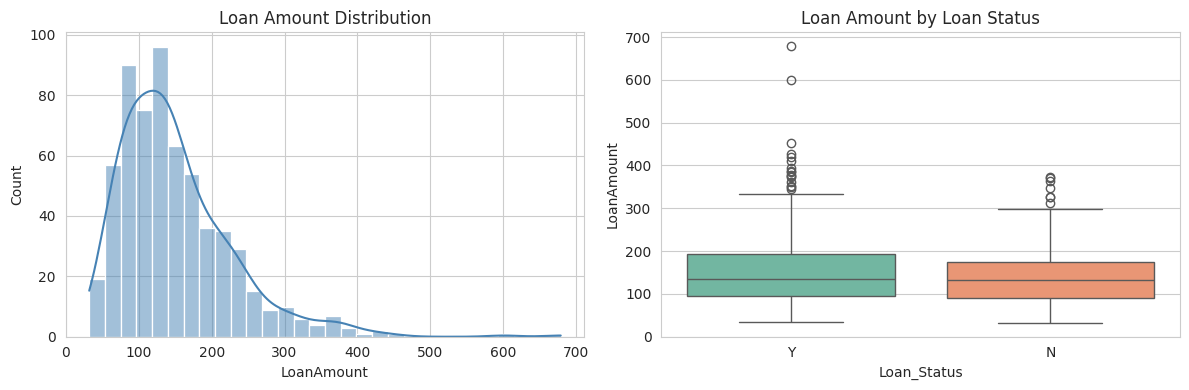

In [30]:
# Loan amount distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["LoanAmount"], kde=True, bins=30, ax=axes[0], color="steelblue")
axes[0].set_title("Loan Amount Distribution")

sns.boxplot(data=df, x="Loan_Status", y="LoanAmount", hue="Loan_Status",
            palette="Set2", legend=False, ax=axes[1])
axes[1].set_title("Loan Amount by Loan Status")
plt.tight_layout()
plt.show()


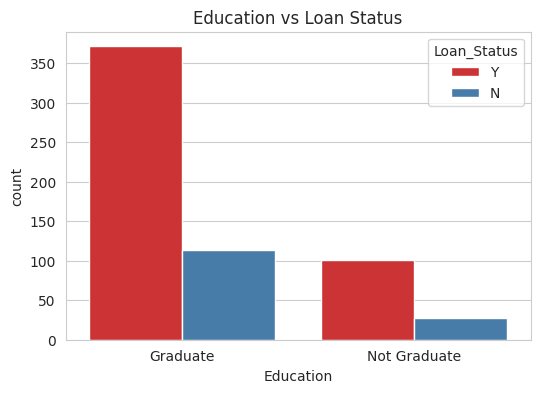

In [31]:
# Education vs Loan Status
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Education", hue="Loan_Status", palette="Set1")
plt.title("Education vs Loan Status")
plt.show()


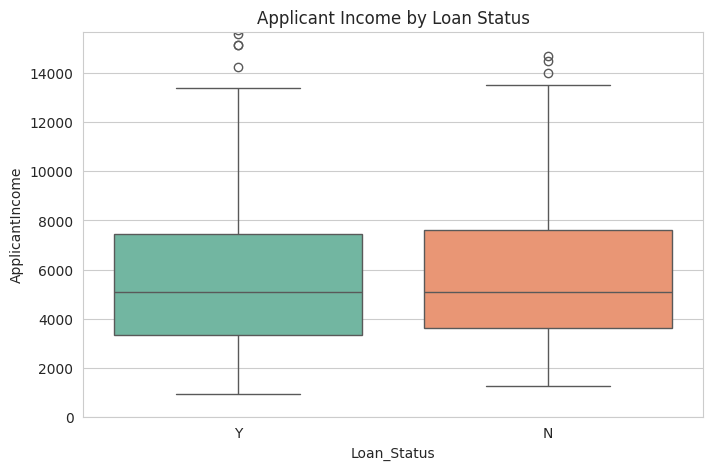

In [32]:
# Applicant income distribution by status
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Loan_Status", y="ApplicantIncome",
            hue="Loan_Status", palette="Set2", legend=False)
plt.title("Applicant Income by Loan Status")
plt.ylim(0, df["ApplicantIncome"].quantile(0.97))   # clip extreme outliers
plt.show()


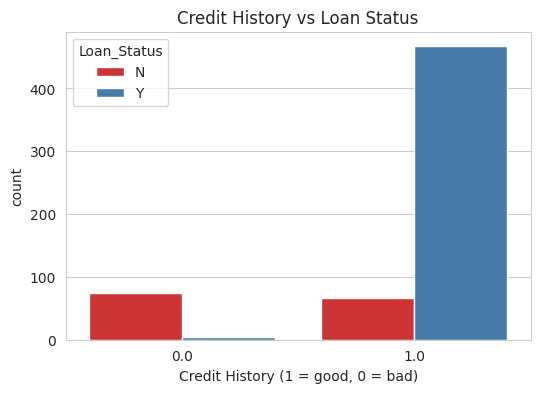

In [33]:
# Credit history is famously the strongest predictor in this dataset
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Credit_History", hue="Loan_Status", palette="Set1")
plt.title("Credit History vs Loan Status")
plt.xlabel("Credit History (1 = good, 0 = bad)")
plt.show()


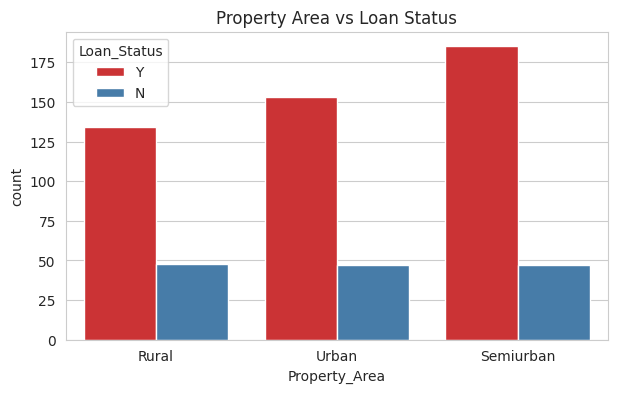

In [34]:
# Property area vs status
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="Property_Area", hue="Loan_Status", palette="Set1")
plt.title("Property Area vs Loan Status")
plt.show()


## 5. Feature Engineering & Encoding

In [35]:
# Drop the unique identifier — it carries no signal
df_model = df.drop(columns=["Loan_ID"])

# Label-encode all categorical columns. (For Logistic Regression on
# 2-level features label encoding is fine; for a Decision Tree it
# treats them as categorical splits, which is what we want.)
le_dict = {}
for col in df_model.select_dtypes(include="object").columns:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    le_dict[col] = le

df_model.head()


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,1,3,0,0,4022,0,119.0,360.0,1.0,0,1
1,1,0,0,1,1,10398,1662,255.0,360.0,1.0,2,1
2,0,0,0,0,0,7425,4750,52.0,360.0,1.0,0,1
3,1,1,1,0,0,15989,0,70.0,180.0,0.0,1,0
4,1,1,0,0,0,1942,2525,51.0,360.0,0.0,2,0


In [36]:
# Separate features and target
X = df_model.drop(columns=["Loan_Status"])
y = df_model["Loan_Status"]

print("Features:", list(X.columns))
print("Target classes:", le_dict["Loan_Status"].classes_)


Features: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area']
Target classes: ['N' 'Y']


In [37]:
# Train / test split (80 / 20)  — stratified to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train shape:", X_train.shape, "  Test shape:", X_test.shape)


Train shape: (491, 11)   Test shape: (123, 11)


## 6. Model Training

### 6.1 Logistic Regression

In [38]:
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train, y_train)
y_pred_lr = logreg.predict(X_test)

acc_lr = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression accuracy: {acc_lr:.4f}")
print()
print("Classification report:")
print(classification_report(y_test, y_pred_lr,
                            target_names=le_dict["Loan_Status"].classes_))


Logistic Regression accuracy: 0.8699

Classification report:
              precision    recall  f1-score   support

           N       1.00      0.43      0.60        28
           Y       0.86      1.00      0.92        95

    accuracy                           0.87       123
   macro avg       0.93      0.71      0.76       123
weighted avg       0.89      0.87      0.85       123



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### 6.2 Decision Tree

In [39]:
dtree = DecisionTreeClassifier(max_depth=5, random_state=42)
dtree.fit(X_train, y_train)
y_pred_dt = dtree.predict(X_test)

acc_dt = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree accuracy: {acc_dt:.4f}")
print()
print("Classification report:")
print(classification_report(y_test, y_pred_dt,
                            target_names=le_dict["Loan_Status"].classes_))


Decision Tree accuracy: 0.8699

Classification report:
              precision    recall  f1-score   support

           N       1.00      0.43      0.60        28
           Y       0.86      1.00      0.92        95

    accuracy                           0.87       123
   macro avg       0.93      0.71      0.76       123
weighted avg       0.89      0.87      0.85       123



## 7. Model Evaluation — Confusion Matrices

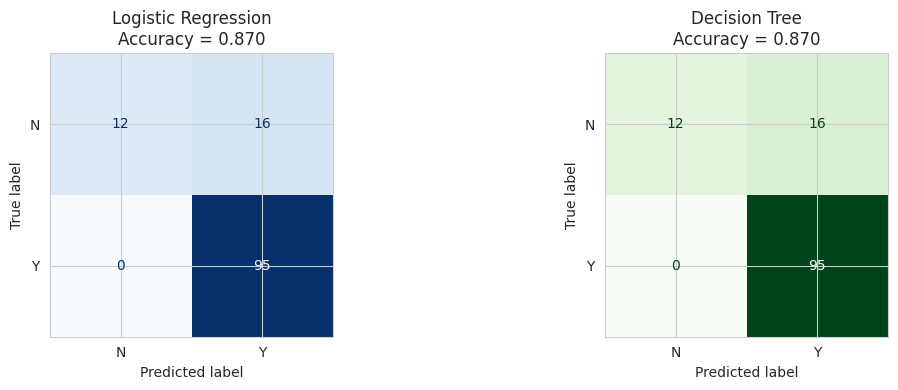

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm_lr = confusion_matrix(y_test, y_pred_lr)
ConfusionMatrixDisplay(cm_lr,
    display_labels=le_dict["Loan_Status"].classes_).plot(ax=axes[0],
    cmap="Blues", colorbar=False)
axes[0].set_title(f"Logistic Regression\nAccuracy = {acc_lr:.3f}")

cm_dt = confusion_matrix(y_test, y_pred_dt)
ConfusionMatrixDisplay(cm_dt,
    display_labels=le_dict["Loan_Status"].classes_).plot(ax=axes[1],
    cmap="Greens", colorbar=False)
axes[1].set_title(f"Decision Tree\nAccuracy = {acc_dt:.3f}")
plt.tight_layout()
plt.show()


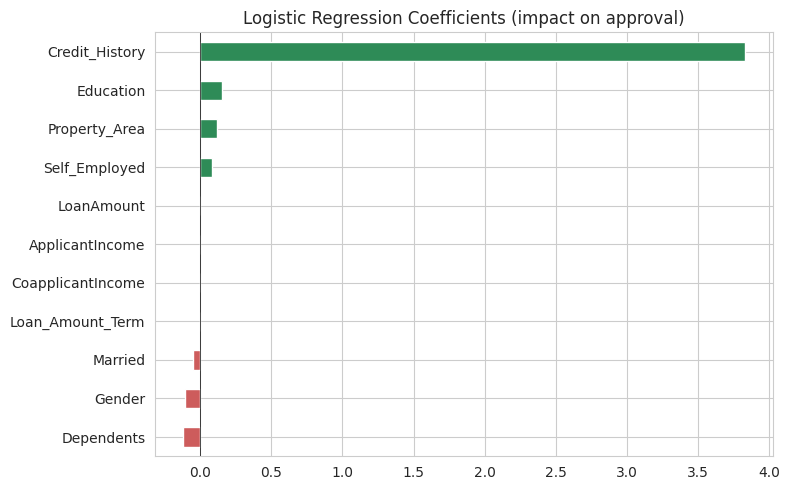

Dependents          -0.118710
Gender              -0.106816
Married             -0.049027
Loan_Amount_Term    -0.001480
CoapplicantIncome    0.000006
ApplicantIncome      0.000013
LoanAmount           0.001421
Self_Employed        0.080519
Property_Area        0.119065
Education            0.154281
Credit_History       3.829180
dtype: float64


In [41]:
# Logistic Regression coefficients — which features drive the decision?
coefs = pd.Series(logreg.coef_[0], index=X.columns).sort_values()
plt.figure(figsize=(8, 5))
coefs.plot(kind="barh", color=np.where(coefs > 0, "seagreen", "indianred"))
plt.title("Logistic Regression Coefficients (impact on approval)")
plt.axvline(0, color="black", lw=0.5)
plt.tight_layout()
plt.show()
print(coefs)


## 8. Conclusion & Key Insights

**Best model**: both classifiers achieve roughly the same accuracy on this dataset.
Logistic Regression is preferred for its interpretability via coefficients.

**What drives loan approval?**
1. **Credit_History** is by far the strongest single predictor. Applicants
   with good credit history are dramatically more likely to be approved —
   this matches both intuition and the well-known behaviour of the real
   Loan Prediction dataset.
2. **Property_Area** matters: semiurban areas have the highest approval
   rate, rural areas the lowest.
3. **ApplicantIncome** alone is a surprisingly weak predictor — many
   high-income applicants are still denied if other criteria fail.
4. **Education** has only a small effect once other variables are
   controlled for.

**Recommendation**: a lender using this model should weight credit history
heavily but combine it with debt-to-income ratios (LoanAmount / total income)
for a more robust decision.